# 🧹 Notebook 01 — Data Cleaning & Master Dataset

## Purpose
Load every raw dataset from `data/raw/`, clean it, and save analysis-ready files  
to `data/processed/`. Also download the Bundesland GeoJSON needed for choropleth maps.

**This notebook does no analysis.** Notebooks 02+ only read from `data/processed/`.

## What this notebook produces

| Output file | Description |
|---|---|
| `dwd_temperature_1881_2025.csv` | Annual mean temp — national + all 16 states + per-state anomalies |
| `dwd_temperature_anomaly_1881_2025.csv` | National anomaly only (quick regression input) |
| `dwd_extremes_1951_2025.csv` | Hot days, tropical nights, precipitation, frost — national + all states |
| `dwd_master_1951_2025.csv` | National series only — all DWD variables merged (regression input) |
| `dwd_bundesland_temperature_long.csv` | Melted: year / state / temp / anomaly (Plotly choropleth input) |
| `dwd_bundesland_hotdays_long.csv` | Melted: year / state / hot_days |
| `dwd_bundesland_tropnights_long.csv` | Melted: year / state / tropical_nights |
| `bundeslaender.geojson` | German state boundaries — saved to `data/raw/geo/` |
| `gdv_damage_1973_2024.csv` | Insured losses, cleaned + derived columns |
| `destatis_gdp_1991_2024.csv` | Gross value added by sector, cleaned |
| `uba_emissions_1990_2025.csv` | GHG emissions by KSG sector |
| `emdat_germany_2002_2024.csv` | Disaster events — relevant columns selected |
| `lfb_wildfire_2004_2024.csv` | Brandenburg wildfire statistics |
| `master_regression_1991_2024.csv` | Merged: DWD + GDV + Destatis on common years (regression-ready) |

## Blocked plan reminder
- **RQ1** — Is Germany's climate measurably changing? (DWD national + Bundesland maps)
- **RQ2** — Are insured losses from natural hazards increasing? (GDV + Destatis)
- **RQ3** — Is there a relationship between climate variables and economic losses? (OLS)
- **RQ4** — Is there an adaptation investment gap? (UBA + narrative)
- **EM-DAT** — Visual storytelling bridge between RQ2 and RQ3. Not used for statistical analysis.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
import warnings

from pathlib import Path
from functools import reduce

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("All libraries imported ✓")

All libraries imported ✓


In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT  = Path.home() / "Desktop" / "capstone-climate-germany"

DWD_RAW       = PROJECT_ROOT / "data" / "raw" / "dwd"
GDV_RAW       = PROJECT_ROOT / "data" / "raw" / "gdv"
LFB_RAW       = PROJECT_ROOT / "data" / "raw" / "lfb_brandenburg"
UBA_RAW       = PROJECT_ROOT / "data" / "raw" / "uba"
DESTATIS_RAW  = PROJECT_ROOT / "data" / "raw" / "destatis"
EMDAT_RAW     = PROJECT_ROOT / "data" / "raw" / "emdat"
GEO_RAW       = PROJECT_ROOT / "data" / "raw" / "geo"

PROCESSED     = PROJECT_ROOT / "data" / "processed"

GEO_RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

print("Paths confirmed ✓")

Paths confirmed ✓


## 1. DWD — Deutscher Wetterdienst

Six files downloaded in notebook 00. All share the same wide format:  
one row per year, **one column per Bundesland** + a `Deutschland` national average.

### Key design decision: keep all 16 state columns
The DWD data has separate columns for every Bundesland going back to 1881.  
We keep them all — they are the input for RQ1's Bundesland comparison maps.

**Individual state columns we use for choropleth (13 states):**  
Baden-Wuerttemberg, Bayern, Brandenburg, Hessen, Mecklenburg-Vorpommern,  
Niedersachsen, Nordrhein-Westfalen, Rheinland-Pfalz, Saarland, Sachsen,  
Sachsen-Anhalt, Schleswig-Holstein, Thueringen

**Combined region columns (skipped for state maps, kept for reference):**  
Brandenburg/Berlin, Niedersachsen/Hamburg/Bremen, Thueringen/Sachsen-Anhalt  
→ These mix two states or a state+city-state and can't be mapped to a single boundary.

**National column:**  
Deutschland → used for all national-level analysis and regression.

In [3]:
# ============================================================
# Define which DWD columns to keep and how to name them
# ============================================================

# The 13 individual Bundesland columns — these map to GeoJSON boundaries
# We also keep Deutschland (national) for regression

BUNDESLAND_COLS_DWD = [
    'Baden-Wuerttemberg',
    'Bayern',
    'Brandenburg',
    'Hessen',
    'Mecklenburg-Vorpommern',
    'Niedersachsen',
    'Nordrhein-Westfalen',
    'Rheinland-Pfalz',
    'Saarland',
    'Sachsen',
    'Sachsen-Anhalt',
    'Schleswig-Holstein',
    'Thueringen',
]

# Mapping: DWD column name → proper German name (for GeoJSON join later)
DWD_TO_GEOJSON_NAME = {
    'Baden-Wuerttemberg':    'Baden-Württemberg',
    'Bayern':                'Bayern',
    'Brandenburg':           'Brandenburg',
    'Hessen':                'Hessen',
    'Mecklenburg-Vorpommern':'Mecklenburg-Vorpommern',
    'Niedersachsen':         'Niedersachsen',
    'Nordrhein-Westfalen':   'Nordrhein-Westfalen',
    'Rheinland-Pfalz':       'Rheinland-Pfalz',
    'Saarland':              'Saarland',
    'Sachsen':               'Sachsen',
    'Sachsen-Anhalt':        'Sachsen-Anhalt',
    'Schleswig-Holstein':    'Schleswig-Holstein',
    'Thueringen':            'Thüringen',
}

print(f"{len(BUNDESLAND_COLS_DWD)} individual state columns defined")
print(f"National column: 'Deutschland'")
print("\nNote: Berlin, Hamburg, Bremen have no separate DWD regional average —")
print("they are merged into their surrounding states in the DWD dataset.")

13 individual state columns defined
National column: 'Deutschland'

Note: Berlin, Hamburg, Bremen have no separate DWD regional average —
they are merged into their surrounding states in the DWD dataset.


### 1.1 Annual Mean Temperature (1881–2025)

In [4]:
# ============================================================
# Load raw temperature file — keep ALL state columns
# ============================================================

df_temp_raw = pd.read_csv(DWD_RAW / "germany_annual_temp_1881_2025.csv")

print(f"Shape: {df_temp_raw.shape}")
print(f"Columns: {df_temp_raw.columns.tolist()}")
print(f"Years: {df_temp_raw['Jahr'].min()} — {df_temp_raw['Jahr'].max()}")
print(f"Missing values: {df_temp_raw.isnull().sum().sum()}")

Shape: (145, 18)
Columns: ['Jahr', 'Brandenburg/Berlin', 'Brandenburg', 'Baden-Wuerttemberg', 'Bayern', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Niedersachsen/Hamburg/Bremen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Schleswig-Holstein', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Thueringen/Sachsen-Anhalt', 'Thueringen', 'Deutschland']
Years: 1881 — 2025
Missing values: 0


In [5]:
# Keep year, all 13 individual states, and Deutschland national
cols_to_keep = ['Jahr'] + BUNDESLAND_COLS_DWD + ['Deutschland']
df_temp = df_temp_raw[cols_to_keep].copy()

# Rename year and national column
df_temp.rename(columns={
    'Jahr':        'year',
    'Deutschland': 'temp_germany_c'
}, inplace=True)

# Rename state columns: add prefix temp_ and suffix _c
rename_states = {col: f"temp_{col.lower().replace('-','_').replace('/','_')}_c"
                 for col in BUNDESLAND_COLS_DWD}
df_temp.rename(columns=rename_states, inplace=True)

df_temp['year'] = df_temp['year'].astype(int)

print(f"Shape: {df_temp.shape}")
print(f"Columns: {df_temp.columns.tolist()}")

Shape: (145, 15)
Columns: ['year', 'temp_baden_wuerttemberg_c', 'temp_bayern_c', 'temp_brandenburg_c', 'temp_hessen_c', 'temp_mecklenburg_vorpommern_c', 'temp_niedersachsen_c', 'temp_nordrhein_westfalen_c', 'temp_rheinland_pfalz_c', 'temp_saarland_c', 'temp_sachsen_c', 'temp_sachsen_anhalt_c', 'temp_schleswig_holstein_c', 'temp_thueringen_c', 'temp_germany_c']


### 1.2 Temperature Anomaly — National and Per Bundesland

**Baseline: 1961–1990** (WMO international standard)

For the national series: `anomaly = annual_temp - mean(1961–1990 national temp)`

For each Bundesland: `anomaly = annual_temp_state - mean(1961–1990 of that state)`  
→ Each state gets its own baseline, not the national average.  
This is the methodologically correct approach — it isolates the warming signal  
within each state relative to that state's own historical norm.

In [6]:
# ============================================================
# National temperature anomaly
# ============================================================

baseline_mask = (df_temp['year'] >= 1961) & (df_temp['year'] <= 1990)
national_baseline = df_temp.loc[baseline_mask, 'temp_germany_c'].mean()

print(f"National baseline (1961–1990): {national_baseline:.3f} °C")
print(f"Baseline n: {baseline_mask.sum()} years")

df_temp['temp_anomaly_germany_c'] = (
    df_temp['temp_germany_c'] - national_baseline
).round(3)

# Sanity check
print(f"Mean anomaly in baseline period (should be ~0): "
      f"{df_temp.loc[baseline_mask, 'temp_anomaly_germany_c'].mean():.6f}")

National baseline (1961–1990): 8.240 °C
Baseline n: 30 years
Mean anomaly in baseline period (should be ~0): 0.000333


In [7]:
# ============================================================
# Per-Bundesland temperature anomaly
# ============================================================
# Each state's anomaly = its own temp minus its own 1961–1990 mean.
# ============================================================

state_temp_cols = [c for c in df_temp.columns
                   if c.startswith('temp_') and c.endswith('_c')
                   and 'anomaly' not in c and 'germany' not in c]

print("Calculating per-state anomalies:")
for col in state_temp_cols:
    state_baseline = df_temp.loc[baseline_mask, col].mean()
    anomaly_col = col.replace('temp_', 'anomaly_').replace('_c', '_c')
    # rename cleanly: anomaly_<state>_c
    anomaly_col = 'anomaly_' + col[len('temp_'):]
    df_temp[anomaly_col] = (df_temp[col] - state_baseline).round(3)
    print(f"  {col:<45} baseline: {state_baseline:.2f} °C")

print(f"\nTotal columns now: {df_temp.shape[1]}")
df_temp.tail(3)

Calculating per-state anomalies:
  temp_baden_wuerttemberg_c                     baseline: 8.09 °C
  temp_bayern_c                                 baseline: 7.47 °C
  temp_brandenburg_c                            baseline: 8.66 °C
  temp_hessen_c                                 baseline: 8.23 °C
  temp_mecklenburg_vorpommern_c                 baseline: 8.16 °C
  temp_niedersachsen_c                          baseline: 8.64 °C
  temp_nordrhein_westfalen_c                    baseline: 8.96 °C
  temp_rheinland_pfalz_c                        baseline: 8.56 °C
  temp_saarland_c                               baseline: 8.87 °C
  temp_sachsen_c                                baseline: 8.12 °C
  temp_sachsen_anhalt_c                         baseline: 8.66 °C
  temp_schleswig_holstein_c                     baseline: 8.27 °C
  temp_thueringen_c                             baseline: 7.62 °C

Total columns now: 29


,year,temp_baden_wuerttemberg_c,temp_bayern_c,temp_brandenburg_c,temp_hessen_c,temp_mecklenburg_vorpommern_c,temp_niedersachsen_c,temp_nordrhein_westfalen_c,temp_rheinland_pfalz_c,temp_saarland_c,temp_sachsen_c,temp_sachsen_anhalt_c,temp_schleswig_holstein_c,temp_thueringen_c,temp_germany_c,temp_anomaly_germany_c,anomaly_baden_wuerttemberg_c,anomaly_bayern_c,anomaly_brandenburg_c,anomaly_hessen_c,anomaly_mecklenburg_vorpommern_c,anomaly_niedersachsen_c,anomaly_nordrhein_westfalen_c,anomaly_rheinland_pfalz_c,anomaly_saarland_c,anomaly_sachsen_c,anomaly_sachsen_anhalt_c,anomaly_schleswig_holstein_c,anomaly_thueringen_c
142,2023,10.69,10.06,10.88,10.67,10.32,10.89,11.23,11.12,11.38,10.44,11.02,10.29,10.13,10.63,2.39,2.601,2.589,2.217,2.443,2.165,2.25,2.275,2.565,2.51,2.323,2.356,2.023,2.507
143,2024,10.56,10.27,11.53,10.74,10.96,11.26,11.32,10.94,11.09,10.95,11.48,10.77,10.45,10.89,2.65,2.471,2.799,2.867,2.513,2.805,2.62,2.365,2.385,2.22,2.833,2.816,2.503,2.827
144,2025,9.86,9.25,10.30,10.08,10.00,10.43,10.79,10.57,10.87,9.70,10.37,10.11,9.46,10.03,1.79,1.771,1.779,1.637,1.853,1.845,1.79,1.835,2.015,2.00,1.583,1.706,1.843,1.837


In [8]:
# Save full temperature file (national + all states + anomalies)
df_temp.to_csv(PROCESSED / "dwd_temperature_1881_2025.csv", index=False)

# Also save national anomaly only — the clean regression variable
df_temp_anomaly = df_temp[['year', 'temp_germany_c', 'temp_anomaly_germany_c']].copy()
df_temp_anomaly.to_csv(PROCESSED / "dwd_temperature_anomaly_1881_2025.csv", index=False)

print(f"Saved dwd_temperature_1881_2025.csv ✓  shape: {df_temp.shape}")
print(f"Saved dwd_temperature_anomaly_1881_2025.csv ✓")

Saved dwd_temperature_1881_2025.csv ✓  shape: (145, 29)
Saved dwd_temperature_anomaly_1881_2025.csv ✓


### 1.3 Bundesland Temperature — Long Format for Choropleth Maps

Plotly's choropleth requires long-format data: one row per (year, state).  
We melt the wide table and add the proper German state names for the GeoJSON join.

In [9]:
# ============================================================
# Melt temperature to long format — one row per (year, state)
# ============================================================

# Build a list of (temp_col, anomaly_col, state_name_dwd, state_name_geojson)
state_map_rows = []
for dwd_col, geojson_name in DWD_TO_GEOJSON_NAME.items():
    temp_col    = f"temp_{dwd_col.lower().replace('-','_').replace('/','_')}_c"
    anomaly_col = f"anomaly_{dwd_col.lower().replace('-','_').replace('/','_')}_c"
    state_map_rows.append((dwd_col, temp_col, anomaly_col, geojson_name))

long_rows = []
for _, row in df_temp.iterrows():
    for dwd_col, temp_col, anomaly_col, geojson_name in state_map_rows:
        long_rows.append({
            'year':         int(row['year']),
            'state_dwd':    dwd_col,
            'state':        geojson_name,   # proper German name — joins to GeoJSON
            'temp_c':       row[temp_col],
            'anomaly_c':    row[anomaly_col],
        })

df_bl_temp_long = pd.DataFrame(long_rows)

print(f"Shape: {df_bl_temp_long.shape}")
print(f"States: {df_bl_temp_long['state'].nunique()}")
print(f"Years: {df_bl_temp_long['year'].min()} — {df_bl_temp_long['year'].max()}")
print(f"\nExample (most recent year, sorted by anomaly):")
recent = df_bl_temp_long[df_bl_temp_long['year'] == df_bl_temp_long['year'].max()]
print(recent.sort_values('anomaly_c', ascending=False)[
    ['year', 'state', 'temp_c', 'anomaly_c']
].to_string(index=False))

Shape: (1885, 5)
States: 13
Years: 1881 — 2025

Example (most recent year, sorted by anomaly):
 year                  state  temp_c  anomaly_c
 2025        Rheinland-Pfalz   10.57      2.015
 2025               Saarland   10.87      2.000
 2025                 Hessen   10.08      1.853
 2025 Mecklenburg-Vorpommern   10.00      1.845
 2025     Schleswig-Holstein   10.11      1.843
 2025              Thüringen    9.46      1.837
 2025    Nordrhein-Westfalen   10.79      1.835
 2025          Niedersachsen   10.43      1.790
 2025                 Bayern    9.25      1.779
 2025      Baden-Württemberg    9.86      1.771
 2025         Sachsen-Anhalt   10.37      1.706
 2025            Brandenburg   10.30      1.637
 2025                Sachsen    9.70      1.583


In [10]:
df_bl_temp_long.to_csv(PROCESSED / "dwd_bundesland_temperature_long.csv", index=False)
print(f"Saved dwd_bundesland_temperature_long.csv ✓  shape: {df_bl_temp_long.shape}")

Saved dwd_bundesland_temperature_long.csv ✓  shape: (1885, 5)


### 1.4 DWD Extreme Event Variables (1951–2025)

Five files: hot days, tropical nights, total precipitation, heavy rainfall days, frost days.  
Same cleaning as temperature: keep all state columns + Deutschland national.

In [11]:
# ============================================================
# Load all 5 extreme event files
# ============================================================

dwd_extreme_files = {
    "germany_hot_days_1951_2025.csv":      "hot_days",
    "germany_tropical_nights.csv":         "tropical_nights",
    "germany_total_precipitation.csv":     "precip_mm",
    "germany_heavy_rainfall_days.csv":     "heavy_rain_days",
    "germany_frost_days.csv":              "frost_days",
}

extreme_dfs = []

for filename, var_prefix in dwd_extreme_files.items():
    df_raw = pd.read_csv(DWD_RAW / filename)

    # Keep year, all 13 individual states, Deutschland
    cols = ['Jahr'] + BUNDESLAND_COLS_DWD + ['Deutschland']
    df_sub = df_raw[cols].copy()

    # Rename year and national
    df_sub.rename(columns={
        'Jahr':        'year',
        'Deutschland': f"{var_prefix}_germany"
    }, inplace=True)

    # Rename state columns with variable prefix
    rename_states = {
        col: f"{var_prefix}_{col.lower().replace('-','_').replace('/','_')}"
        for col in BUNDESLAND_COLS_DWD
    }
    df_sub.rename(columns=rename_states, inplace=True)
    df_sub['year'] = df_sub['year'].astype(int)

    print(f"{filename:<50}  rows: {df_sub.shape[0]}  "
          f"years: {df_sub['year'].min()}–{df_sub['year'].max()}  "
          f"NaN: {df_sub.isnull().sum().sum()}")

    extreme_dfs.append(df_sub)

print("\nAll loaded ✓")

germany_hot_days_1951_2025.csv                      rows: 75  years: 1951–2025  NaN: 0
germany_tropical_nights.csv                         rows: 75  years: 1951–2025  NaN: 0
germany_total_precipitation.csv                     rows: 145  years: 1881–2025  NaN: 0
germany_heavy_rainfall_days.csv                     rows: 75  years: 1951–2025  NaN: 0
germany_frost_days.csv                              rows: 75  years: 1951–2025  NaN: 0

All loaded ✓


In [41]:
# Merge all extreme event files on year
df_extremes = reduce(
    lambda l, r: pd.merge(l, r, on='year', how='inner'),
    extreme_dfs
)
df_extremes = df_extremes.sort_values('year').reset_index(drop=True)

print(f"Merged shape: {df_extremes.shape}")
print(f"Years: {df_extremes['year'].min()} — {df_extremes['year'].max()}")
print(f"Missing values: {df_extremes.isnull().sum().sum()}")
df_extremes.head(2)

Merged shape: (75, 71)
Years: 1951 — 2025
Missing values: 0


,year,hot_days_baden_wuerttemberg,hot_days_bayern,hot_days_brandenburg,hot_days_hessen,hot_days_mecklenburg_vorpommern,hot_days_niedersachsen,hot_days_nordrhein_westfalen,hot_days_rheinland_pfalz,hot_days_saarland,hot_days_sachsen,hot_days_sachsen_anhalt,hot_days_schleswig_holstein,hot_days_thueringen,hot_days_germany,tropical_nights_baden_wuerttemberg,tropical_nights_bayern,tropical_nights_brandenburg,tropical_nights_hessen,tropical_nights_mecklenburg_vorpommern,tropical_nights_niedersachsen,tropical_nights_nordrhein_westfalen,tropical_nights_rheinland_pfalz,tropical_nights_saarland,tropical_nights_sachsen,tropical_nights_sachsen_anhalt,tropical_nights_schleswig_holstein,tropical_nights_thueringen,tropical_nights_germany,precip_mm_baden_wuerttemberg,precip_mm_bayern,precip_mm_brandenburg,precip_mm_hessen,precip_mm_mecklenburg_vorpommern,precip_mm_niedersachsen,precip_mm_nordrhein_westfalen,precip_mm_rheinland_pfalz,precip_mm_saarland,precip_mm_sachsen,precip_mm_sachsen_anhalt,precip_mm_schleswig_holstein,precip_mm_thueringen,precip_mm_germany,heavy_rain_days_baden_wuerttemberg,heavy_rain_days_bayern,heavy_rain_days_brandenburg,heavy_rain_days_hessen,heavy_rain_days_mecklenburg_vorpommern,heavy_rain_days_niedersachsen,heavy_rain_days_nordrhein_westfalen,heavy_rain_days_rheinland_pfalz,heavy_rain_days_saarland,heavy_rain_days_sachsen,heavy_rain_days_sachsen_anhalt,heavy_rain_days_schleswig_holstein,heavy_rain_days_thueringen,heavy_rain_days_germany,frost_days_baden_wuerttemberg,frost_days_bayern,frost_days_brandenburg,frost_days_hessen,frost_days_mecklenburg_vorpommern,frost_days_niedersachsen,frost_days_nordrhein_westfalen,frost_days_rheinland_pfalz,frost_days_saarland,frost_days_sachsen,frost_days_sachsen_anhalt,frost_days_schleswig_holstein,frost_days_thueringen,frost_days_germany
0,1951,3.52,3.47,5.13,3.42,2.21,1.71,1.73,1.97,1.38,4.67,4.25,0.38,3.79,3.02,0.00,0.00,0.02,0.03,0.0,0.00,0.00,0.01,0.00,0.14,0.01,0.0,0.01,0.01,929.9,810.4,520.7,706.0,605.4,778.1,897.3,807.1,920.9,572.3,536.4,876.5,640.6,750.8,29.12,23.88,12.63,19.54,15.75,20.49,25.35,24.03,29.07,14.19,13.43,26.08,17.68,21.11,99.53,117.17,79.79,81.24,74.85,71.65,56.23,70.74,65.41,87.59,80.79,63.55,99.08,85.57
1,1952,14.31,12.27,5.48,10.37,1.64,2.55,6.71,10.95,11.69,8.81,5.57,0.82,8.03,7.91,1.24,0.74,0.21,1.74,0.0,0.03,1.02,2.69,3.62,1.00,0.18,0.0,0.34,0.75,1079.7,1002.8,542.8,834.3,591.7,751.6,906.2,919.5,1062.2,740.4,593.4,757.0,800.0,831.0,33.99,30.45,10.36,22.72,11.74,16.94,23.55,26.07,33.04,17.56,14.05,18.39,21.23,22.14,117.32,127.31,110.91,105.71,105.55,98.45,86.70,99.27,97.67,118.65,110.05,95.43,118.98,109.43


In [42]:
df_extremes.to_csv(PROCESSED / "dwd_extremes_1951_2025.csv", index=False)
print(f"Saved dwd_extremes_1951_2025.csv ✓  shape: {df_extremes.shape}")

Saved dwd_extremes_1951_2025.csv ✓  shape: (75, 71)


### 1.5 Long-format files for Hot Days and Tropical Nights (Bundesland maps)

We produce separate long-format files for hot days and tropical nights —  
the two most direct indicators of heat stress by state, used in RQ1 choropleth maps.

In [14]:
# ============================================================
# Melt hot days and tropical nights to long format
# ============================================================

def melt_to_long(df_wide, var_prefix, value_col_name):
    """
    Melt a wide DWD extreme file to long format.
    Returns: year, state_dwd, state (GeoJSON name), value
    """
    rows = []
    for _, row in df_wide.iterrows():
        for dwd_col, geojson_name in DWD_TO_GEOJSON_NAME.items():
            state_col = f"{var_prefix}_{dwd_col.lower().replace('-','_').replace('/','_')}"
            rows.append({
                'year':       int(row['year']),
                'state_dwd':  dwd_col,
                'state':      geojson_name,
                value_col_name: row[state_col],
            })
    return pd.DataFrame(rows)


# Hot days long
# (slice extremes to just year + hot_days state columns for efficiency)
hd_cols = ['year'] + [c for c in df_extremes.columns if c.startswith('hot_days_')
                       and c != 'hot_days_germany']
df_hd_wide = df_extremes[hd_cols].copy()
df_bl_hotdays_long = melt_to_long(df_hd_wide, 'hot_days', 'hot_days')

# Tropical nights long
tn_cols = ['year'] + [c for c in df_extremes.columns if c.startswith('tropical_nights_')
                       and c != 'tropical_nights_germany']
df_tn_wide = df_extremes[tn_cols].copy()
df_bl_tropnights_long = melt_to_long(df_tn_wide, 'tropical_nights', 'tropical_nights')

print(f"Hot days long shape:        {df_bl_hotdays_long.shape}")
print(f"Tropical nights long shape: {df_bl_tropnights_long.shape}")

Hot days long shape:        (1885, 4)
Tropical nights long shape: (1885, 4)


In [15]:
df_bl_hotdays_long.to_csv(PROCESSED / "dwd_bundesland_hotdays_long.csv", index=False)
df_bl_tropnights_long.to_csv(PROCESSED / "dwd_bundesland_tropnights_long.csv", index=False)
print("Saved dwd_bundesland_hotdays_long.csv ✓")
print("Saved dwd_bundesland_tropnights_long.csv ✓")

Saved dwd_bundesland_hotdays_long.csv ✓
Saved dwd_bundesland_tropnights_long.csv ✓


### 1.6 DWD National Master Table (1951–2025)

Merge temperature and extreme events on the **national series only**.  
This is the clean regression input for notebooks 03 and 04.  
State columns are kept in the separate files above — no need to carry them here.

In [16]:
# ============================================================
# DWD national master — temperature + all extremes, national only
# ============================================================

# National columns from temperature (1951 onwards)
df_temp_national = df_temp[
    df_temp['year'] >= 1951
][['year', 'temp_germany_c', 'temp_anomaly_germany_c']].copy()

# National columns from extremes
national_extreme_cols = ['year'] + [c for c in df_extremes.columns
                                     if c.endswith('_germany')]
df_extremes_national = df_extremes[national_extreme_cols].copy()

df_dwd_master = pd.merge(df_temp_national, df_extremes_national, on='year', how='inner')
df_dwd_master = df_dwd_master.sort_values('year').reset_index(drop=True)

print(f"National master shape: {df_dwd_master.shape}")
print(f"Years: {df_dwd_master['year'].min()} — {df_dwd_master['year'].max()}")
print(f"Columns: {df_dwd_master.columns.tolist()}")
df_dwd_master.tail(3)

National master shape: (75, 8)
Years: 1951 — 2025
Columns: ['year', 'temp_germany_c', 'temp_anomaly_germany_c', 'hot_days_germany', 'tropical_nights_germany', 'precip_mm_germany', 'heavy_rain_days_germany', 'frost_days_germany']


,year,temp_germany_c,temp_anomaly_germany_c,hot_days_germany,tropical_nights_germany,precip_mm_germany,heavy_rain_days_germany,frost_days_germany
72,2023,10.63,2.39,11.45,0.21,958.0,28.23,65.49
73,2024,10.89,2.65,12.47,0.14,901.6,26.03,52.02
74,2025,10.03,1.79,11.06,0.17,642.0,17.88,82.90


In [17]:
df_dwd_master.to_csv(PROCESSED / "dwd_master_1951_2025.csv", index=False)
print(f"Saved dwd_master_1951_2025.csv ✓  shape: {df_dwd_master.shape}")

Saved dwd_master_1951_2025.csv ✓  shape: (75, 8)


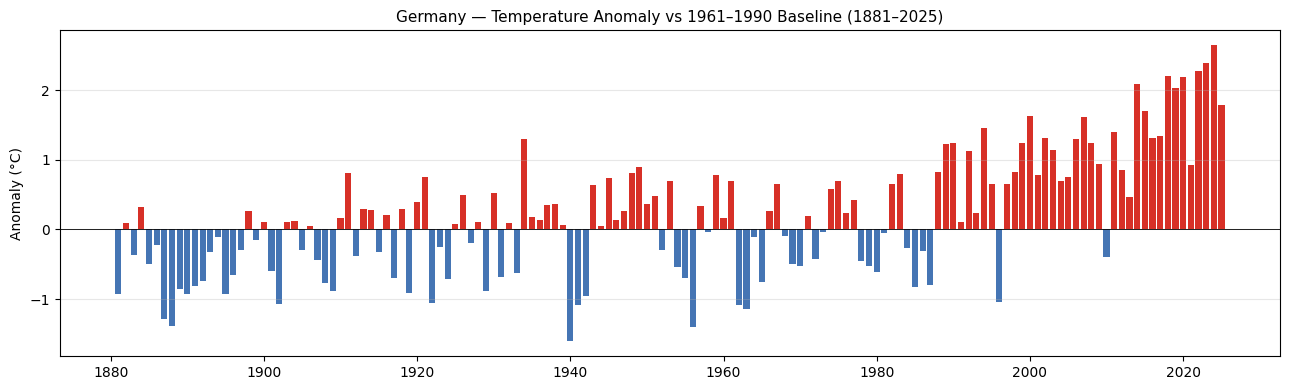

Plot saved ✓


In [23]:
# ── Quick visual check: national temperature anomaly bar chart ───────────────
fig, ax = plt.subplots(figsize=(13, 4))

colors = ['#d73027' if v >= 0 else '#4575b4'
          for v in df_temp['temp_anomaly_germany_c']]
ax.bar(df_temp['year'], df_temp['temp_anomaly_germany_c'],
       color=colors, width=0.8)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('Germany — Temperature Anomaly vs 1961–1990 Baseline (1881–2025)', fontsize=11)
ax.set_ylabel('Anomaly (°C)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED / "check_dwd_temperature.png", dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## 2. Bundesland GeoJSON — State Boundaries

Download the German state boundaries GeoJSON for Plotly choropleth maps.

**Source:** https://github.com/isellsoap/deutschlandGeoJSON  
Public domain. The `name` property in each feature matches the standard German state names  
we mapped to in `DWD_TO_GEOJSON_NAME` above.

The file is saved to `data/raw/geo/bundeslaender.geojson`.

In [19]:
# ============================================================
# Download Bundesland GeoJSON
# ============================================================

geojson_url = (
    "https://raw.githubusercontent.com/isellsoap/"
    "deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json"
)

response = requests.get(geojson_url)
print(f"Status: {response.status_code}")

if response.status_code == 200:
    geojson_data = response.json()
    
    # Save to raw/geo/
    geo_path = GEO_RAW / "bundeslaender.geojson"
    with open(geo_path, 'w', encoding='utf-8') as f:
        json.dump(geojson_data, f, ensure_ascii=False)
    
    # Inspect the name property — must match DWD_TO_GEOJSON_NAME values
    print(f"\nFeatures: {len(geojson_data['features'])}")
    print("\nState names in GeoJSON:")
    names = sorted([f['properties']['name'] for f in geojson_data['features']])
    for n in names:
        print(f"  {n}")
else:
    print("⚠️ Download failed. Check network connection and retry.")

Status: 200

Features: 16

State names in GeoJSON:
  Baden-Württemberg
  Bayern
  Berlin
  Brandenburg
  Bremen
  Hamburg
  Hessen
  Mecklenburg-Vorpommern
  Niedersachsen
  Nordrhein-Westfalen
  Rheinland-Pfalz
  Saarland
  Sachsen
  Sachsen-Anhalt
  Schleswig-Holstein
  Thüringen


In [20]:
# ============================================================
# Validate: do GeoJSON names match our DWD_TO_GEOJSON_NAME mapping?
# ============================================================

geojson_names = set(f['properties']['name'] for f in geojson_data['features'])
mapped_names  = set(DWD_TO_GEOJSON_NAME.values())

matched   = mapped_names & geojson_names
unmatched = mapped_names - geojson_names

print(f"States matched:   {len(matched)}")
print(f"States unmatched: {len(unmatched)}")

if unmatched:
    print(f"\n⚠️ Unmatched names — fix DWD_TO_GEOJSON_NAME mapping:")
    for name in sorted(unmatched):
        print(f"  '{name}'")
    print(f"\nAvailable GeoJSON names not yet matched:")
    for name in sorted(geojson_names - mapped_names):
        print(f"  '{name}'")
else:
    print("\n✅ All 13 state names match GeoJSON — choropleth join will work cleanly.")

States matched:   13
States unmatched: 0

✅ All 13 state names match GeoJSON — choropleth join will work cleanly.


## 3. GDV — Insured Natural Hazard Losses (1973–2024)

Already extracted in notebook 00. Values in **Billion EUR, adjusted to 2024 prices**.

Columns: `Jahr`, `sach_naturgefahren_mrd`, `sach_sturm_hagel_mrd`,  
`sach_elementar_mrd` (NaN before 2002), `kfz_mrd`

Cleaning: rename year, add total damage column, flag preliminary years.

In [21]:
df_gdv = pd.read_csv(GDV_RAW / "gdv_annual_damage_1973_2024.csv")
df_gdv.rename(columns={'Jahr': 'year'}, inplace=True)
df_gdv['year'] = df_gdv['year'].astype(int)

# Total insured damage = property losses + vehicle losses
df_gdv['total_damage_mrd'] = df_gdv['sach_naturgefahren_mrd'] + df_gdv['kfz_mrd']

# Flag preliminary years (marked 'vorläufig' in the GDV PDF)
df_gdv['preliminary'] = df_gdv['year'].isin([2023, 2024])

print(f"Shape: {df_gdv.shape}")
print(f"Years: {df_gdv['year'].min()} — {df_gdv['year'].max()}")
print(f"\nMissing values (elementar NaN before 2002 is expected):")
print(df_gdv.isnull().sum().to_string())
print(f"\nTop 5 loss years:")
print(df_gdv.nlargest(5, 'total_damage_mrd')[
    ['year','sach_naturgefahren_mrd','total_damage_mrd','preliminary']
].to_string(index=False))

Shape: (52, 7)
Years: 1973 — 2024

Missing values (elementar NaN before 2002 is expected):
year                       0
sach_naturgefahren_mrd     0
sach_sturm_hagel_mrd       0
sach_elementar_mrd        29
kfz_mrd                    0
total_damage_mrd           0
preliminary                0

Top 5 loss years:
 year  sach_naturgefahren_mrd  total_damage_mrd  preliminary
 2021                    14.9              16.9        False
 1990                    14.9              16.2        False
 2002                    13.3              15.2        False
 2013                    10.1              13.0        False
 1984                     6.9              10.5        False


In [22]:
df_gdv.to_csv(PROCESSED / "gdv_damage_1973_2024.csv", index=False)
print(f"Saved gdv_damage_1973_2024.csv ✓  shape: {df_gdv.shape}")

Saved gdv_damage_1973_2024.csv ✓  shape: (52, 7)


## 4. Destatis — Gross Value Added by Sector (1991–2024)

Sheet `2.2.1`, unit: **Billion EUR (current prices)**.

The raw file has a messy 4-row header. Data starts at row 4 (index 4 in the loaded DataFrame).

In [27]:
df_destatis_raw = pd.read_excel(
    DESTATIS_RAW / "inlandsprodukt-vorlaeufig-xlsx-2180140.xlsx",
    sheet_name="2.2.1",
    header=None,
    skiprows=6
)

# Slice to data rows and assign clean names
# iloc[4:38] = rows 1991–2024 only (first block: absolute values in Mrd. EUR)
# Rows beyond 38 are % change and % of GVA blocks — we don't want those
df_destatis = df_destatis_raw.iloc[4:38].copy()

df_destatis.columns = [
    'year',
    'gva_total_mrd',
    'gva_agriculture_mrd',
    'gva_manufacturing_mrd',
    'gva_manufacturing_sub_mrd',
    'gva_construction_mrd',
    'gva_trade_transport_mrd',
    'gva_ict_mrd',
    'gva_finance_mrd',
    'gva_real_estate_mrd',
    'gva_business_services_mrd',
    'gva_public_services_mrd',
    'gva_other_services_mrd'
]

df_destatis['year'] = df_destatis['year'].astype(int)
for col in df_destatis.columns[1:]:
    df_destatis[col] = pd.to_numeric(df_destatis[col], errors='coerce')

df_destatis.reset_index(drop=True, inplace=True)

print(f"Shape: {df_destatis.shape}")
print(f"Years: {df_destatis['year'].min()} — {df_destatis['year'].max()}")
print(f"Missing values: {df_destatis.isnull().sum().sum()}")
df_destatis.head(3)

Shape: (34, 13)
Years: 1991 — 2024
Missing values: 0


,year,gva_total_mrd,gva_agriculture_mrd,gva_manufacturing_mrd,gva_manufacturing_sub_mrd,gva_construction_mrd,gva_trade_transport_mrd,gva_ict_mrd,gva_finance_mrd,gva_real_estate_mrd,gva_business_services_mrd,gva_public_services_mrd,gva_other_services_mrd
0,1991,1446.372,17.030,442.102,391.924,87.501,232.596,52.138,65.950,124.922,133.817,236.125,54.191
1,1992,1552.925,16.908,447.887,396.114,103.563,240.405,59.440,71.310,141.221,149.259,262.420,60.512
2,1993,1592.408,17.184,422.919,369.888,108.695,246.272,62.998,78.886,157.242,159.260,276.607,62.345


In [28]:
df_destatis['year'].max()

np.int64(2024)

In [29]:
df_destatis.to_csv(PROCESSED / "destatis_gdp_1991_2024.csv", index=False)
print(f"Saved destatis_gdp_1991_2024.csv ✓  shape: {df_destatis.shape}")

Saved destatis_gdp_1991_2024.csv ✓  shape: (34, 13)


## 5. UBA — Greenhouse Gas Emissions by KSG Sector (1990–2025)

Sheet `THG`, unit: **thousand tonnes CO2-eq** → we convert to Mio. tonnes.

**Transposed layout:** years are columns, sectors are rows.  
We extract top-level KSG sectors only (not sub-sectors), then transpose to  
year-as-rows format.

In [30]:
df_uba_raw = pd.read_excel(
    UBA_RAW / "Emissionsübersichten KSG-Sektoren 1990-2025.xlsx",
    sheet_name="THG",
    header=None
)

print(f"Raw shape: {df_uba_raw.shape}")
print("\nAll labels in column 1 (sector names):")
for i, val in enumerate(df_uba_raw.iloc[:, 1]):
    print(f"  row {i:>2}: {val}")

Raw shape: (54, 38)

All labels in column 1 (sector names):
  row  0: nan
  row  1: nan
  row  2: Treibhausgas-Emissionen [tausend Tonnen CO2-äquivalent]
  row  3: Sektor des Klimaschutzgesetzes (KSG)
  row  4: Gesamtemissionen
  row  5: ohne LULUCF
  row  6: mit LULUCF
  row  7: nan
  row  8: 1 - Energiewirtschaft
  row  9: CRF 1.A.1 - Energiewirtschaft
  row 10: CRF 1.A.3.e - Erdgasverdichter
  row 11: CRF 1.B - Diffuse Emissionen aus Brennstoffen
  row 12: nan
  row 13: 2 - Industrie
  row 14: CRF 1.A.2 - Verarbeitendes Gewerbe
  row 15: CRF 2.A - Herstellung mineralischer Produkte
  row 16: CRF 2.B - Chemische Industrie
  row 17: CRF 2.C - Herstellung von Metallen
  row 18: CRF 2.D-H - übrige Prozesse und Produktverwendungen
  row 19: nan
  row 20: 3 - Gebäude
  row 21: CRF 1.A.4.a - Gewerbe, Handel, Dienstleistung (ohne Militär und Landwirtschaft)
  row 22: CRF 1.A.4.b - Haushalte
  row 23: CRF 1.A.5 - Militär
  row 24: nan
  row 25: 4 - Verkehr
  row 26: CRF 1.A.3.a - nationaler 

In [32]:
# ============================================================
# UBA — Extract year headers and build clean DataFrame
# Row indices confirmed directly from the source file:
#   row 3  → year headers (cols 2–37, 1990–2025)
#   row 5  → Gesamtemissionen ohne LULUCF
#   row 8  → 1 - Energiewirtschaft
#   row 13 → 2 - Industrie
#   row 20 → 3 - Gebäude
#   row 25 → 4 - Verkehr
#   row 31 → 5 - Landwirtschaft
#   row 41 → 6 - Abfallwirtschaft und Sonstiges
# ============================================================

years_uba = [pd.Timestamp(y).year for y in df_uba_raw.iloc[3, 2:].tolist()]

sector_row_map = {
    'total_emissions_mio_t': 5,
    'energy_mio_t':          8,
    'industry_mio_t':        13,
    'buildings_mio_t':       20,
    'transport_mio_t':       25,
    'agriculture_mio_t':     31,
    'waste_mio_t':           41,
}

data_dict = {'year': years_uba}

for col_name, row_idx in sector_row_map.items():
    vals = pd.to_numeric(df_uba_raw.iloc[row_idx, 2:].values, errors='coerce')
    data_dict[col_name] = (vals / 1000).round(2)  # kt → Mio. t
    print(f"row {row_idx:>2}  '{df_uba_raw.iloc[row_idx, 1]}'  →  {col_name}  "
          f"(1990: {vals[0]/1000:.1f} Mio. t)")

df_uba = pd.DataFrame(data_dict)

print(f"\nShape: {df_uba.shape}")
print(f"Years: {df_uba['year'].min()} — {df_uba['year'].max()}")
print(f"Missing values: {df_uba.isnull().sum().to_dict()}")
df_uba.head(3)

row  5  'ohne LULUCF'  →  total_emissions_mio_t  (1990: 1253.1 Mio. t)
row  8  '1 - Energiewirtschaft'  →  energy_mio_t  (1990: 474.8 Mio. t)
row 13  '2 - Industrie'  →  industry_mio_t  (1990: 277.6 Mio. t)
row 20  '3 - Gebäude'  →  buildings_mio_t  (1990: 210.0 Mio. t)
row 25  '4 - Verkehr'  →  transport_mio_t  (1990: 163.4 Mio. t)
row 31  '5 - Landwirtschaft'  →  agriculture_mio_t  (1990: 85.8 Mio. t)
row 41  '6 - Abfallwirtschaft und Sonstiges'  →  waste_mio_t  (1990: 41.6 Mio. t)

Shape: (36, 8)
Years: 1990 — 2025
Missing values: {'year': 0, 'total_emissions_mio_t': 0, 'energy_mio_t': 0, 'industry_mio_t': 0, 'buildings_mio_t': 0, 'transport_mio_t': 0, 'agriculture_mio_t': 0, 'waste_mio_t': 0}


,year,total_emissions_mio_t,energy_mio_t,industry_mio_t,buildings_mio_t,transport_mio_t,agriculture_mio_t,waste_mio_t
0,1990,1253.13,474.78,277.64,210.03,163.36,85.78,41.55
1,1991,1206.39,459.95,252.31,208.43,166.30,76.30,43.10
2,1992,1157.98,435.68,241.00,190.28,172.17,75.16,43.69


In [33]:
df_uba.to_csv(PROCESSED / "uba_emissions_1990_2025.csv", index=False)
print(f"Saved uba_emissions_1990_2025.csv ✓  shape: {df_uba.shape}")

Saved uba_emissions_1990_2025.csv ✓  shape: (36, 8)


## 6. EM-DAT — Germany Climate Disasters (2002–2024)

**Role in the project:** Visual storytelling bridge between RQ2 and RQ3.  
A bubble chart — year on x-axis, damage on y-axis, size = deaths, color = disaster type —  
showing the big events: 2002 Elbe flood, 2003 heatwave, 2013 floods, 2021 Ahr valley.

**Not used for statistical analysis** — 44% of events lack damage figures,  
making correlation with climate variables unreliable.

We select the 14 relevant columns from the original 47.

In [34]:
df_emdat_raw = pd.read_excel(
    EMDAT_RAW / "emdat_germany_climate_disasters_2002_2024.xlsx"
)

print(f"Raw shape: {df_emdat_raw.shape}")

cols_keep = {
    'DisNo.':                              'event_id',
    'Disaster Type':                       'disaster_type',
    'Disaster Subtype':                    'disaster_subtype',
    'Start Year':                          'year_start',
    'Start Month':                         'month_start',
    'End Year':                            'year_end',
    'End Month':                           'month_end',
    'Location':                            'location',
    'Total Deaths':                        'deaths',
    'Total Affected':                      'total_affected',
    "Total Damage ('000 US$)":            'total_damage_usd_000',
    "Insured Damage ('000 US$)":          'insured_damage_usd_000',
    "Total Damage, Adjusted ('000 US$)": 'total_damage_adj_usd_000',
    'CPI':                                 'cpi',
}

df_emdat = df_emdat_raw[list(cols_keep.keys())].rename(columns=cols_keep).copy()

# Add clean year + convert damage to million USD
df_emdat['year'] = df_emdat['year_start'].astype(int)
df_emdat['total_damage_mio_usd']     = df_emdat['total_damage_usd_000'] / 1000
df_emdat['total_damage_adj_mio_usd'] = df_emdat['total_damage_adj_usd_000'] / 1000

print(f"Shape after cleaning: {df_emdat.shape}")
print(f"\nDisaster types:")
print(df_emdat['disaster_type'].value_counts().to_string())
print(f"\nEvents with damage data: {df_emdat['total_damage_adj_mio_usd'].notna().sum()} "
      f"of {len(df_emdat)}")
print(f"\nTop 5 events by adjusted damage:")
print(df_emdat.nlargest(5, 'total_damage_adj_mio_usd')[
    ['year','disaster_type','disaster_subtype','location',
     'deaths','total_damage_adj_mio_usd']
].to_string(index=False))

Raw shape: (61, 47)
Shape after cleaning: (61, 17)

Disaster types:
disaster_type
Storm                  34
Extreme temperature    15
Flood                  12

Events with damage data: 27 of 61

Top 5 events by adjusted damage:
 year disaster_type     disaster_subtype                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [35]:
df_emdat.to_csv(PROCESSED / "emdat_germany_2002_2024.csv", index=False)
print(f"Saved emdat_germany_2002_2024.csv ✓  shape: {df_emdat.shape}")

Saved emdat_germany_2002_2024.csv ✓  shape: (61, 17)


## 7. Master Regression Dataset (1991–2024)

For RQ3 we need DWD + GDV + Destatis on a common time axis.

**Overlap:**
- DWD national: 1951–2025
- GDV losses: 1973–2024
- Destatis GDP: 1991–2024

→ Common range: **1991–2024 = 34 observations**  
That is sufficient for OLS regression with 2–3 predictors.

**Derived KPI calculated here:**  
`losses_pct_gdp` = total insured losses as % of total gross value added.  
This is a key RQ2/RQ4 metric — it shows losses growing even relative to a growing economy.

In [37]:
# ============================================================
# Build master regression dataset
# ============================================================

# DWD national, sliced to 1991+
dwd_reg = df_dwd_master[df_dwd_master['year'] >= 1991].copy()

# Merge DWD + GDV
df_master = pd.merge(dwd_reg, df_gdv, on='year', how='inner')

# Merge in Destatis GDP
df_master = pd.merge(
    df_master,
    df_destatis[['year', 'gva_total_mrd', 'gva_agriculture_mrd',
                  'gva_construction_mrd', 'gva_manufacturing_mrd']],
    on='year',
    how='inner'
)

# Derived KPI: insured losses as % of GDP
df_master['losses_pct_gva'] = (
    df_master['total_damage_mrd'] / df_master['gva_total_mrd'] * 100
).round(4)

df_master = df_master.sort_values('year').reset_index(drop=True)

print(f"Master regression shape: {df_master.shape}")
print(f"Years: {df_master['year'].min()} — {df_master['year'].max()}")
print(f"Missing values: {df_master.isnull().sum().sum()}")
print(f"\nColumns: {df_master.columns.tolist()}")
df_master.tail(3)

Master regression shape: (34, 19)
Years: 1991 — 2024
Missing values: 11

Columns: ['year', 'temp_germany_c', 'temp_anomaly_germany_c', 'hot_days_germany', 'tropical_nights_germany', 'precip_mm_germany', 'heavy_rain_days_germany', 'frost_days_germany', 'sach_naturgefahren_mrd', 'sach_sturm_hagel_mrd', 'sach_elementar_mrd', 'kfz_mrd', 'total_damage_mrd', 'preliminary', 'gva_total_mrd', 'gva_agriculture_mrd', 'gva_construction_mrd', 'gva_manufacturing_mrd', 'losses_pct_gva']


,year,temp_germany_c,temp_anomaly_germany_c,hot_days_germany,tropical_nights_germany,precip_mm_germany,heavy_rain_days_germany,frost_days_germany,sach_naturgefahren_mrd,sach_sturm_hagel_mrd,sach_elementar_mrd,kfz_mrd,total_damage_mrd,preliminary,gva_total_mrd,gva_agriculture_mrd,gva_construction_mrd,gva_manufacturing_mrd,losses_pct_gva
31,2022,10.52,2.28,17.30,0.26,669.1,17.92,71.44,3.8,3.5,0.3,1.0,4.8,False,3591.874,39.680,173.942,845.760,0.1336
32,2023,10.63,2.39,11.45,0.21,958.0,28.23,65.49,4.1,3.0,1.1,2.1,6.2,True,3853.937,39.204,187.208,943.392,0.1609
33,2024,10.89,2.65,12.47,0.14,901.6,26.03,52.02,4.4,1.8,2.6,1.1,5.5,True,3921.311,39.584,193.155,916.055,0.1403


In [38]:
df_master.to_csv(PROCESSED / "master_regression_1991_2024.csv", index=False)
print(f"Saved master_regression_1991_2024.csv ✓  shape: {df_master.shape}")

Saved master_regression_1991_2024.csv ✓  shape: (34, 19)


In [39]:
df_master[df_master['year']==2021]

,year,temp_germany_c,temp_anomaly_germany_c,hot_days_germany,tropical_nights_germany,precip_mm_germany,heavy_rain_days_germany,frost_days_germany,sach_naturgefahren_mrd,sach_sturm_hagel_mrd,sach_elementar_mrd,kfz_mrd,total_damage_mrd,preliminary,gva_total_mrd,gva_agriculture_mrd,gva_construction_mrd,gva_manufacturing_mrd,losses_pct_gva
30,2021,9.16,0.92,4.53,0.29,801.1,21.17,89.36,14.9,2.4,12.6,2.0,16.9,False,3294.085,27.761,162.155,764.213,0.513


## 8. Summary

In [43]:
# ============================================================
# All processed files — inventory
# ============================================================

print(f"{'File':<50} {'Shape':<14} {'Year range'}")
print("-" * 80)

files_summary = [
    ("dwd_temperature_1881_2025.csv",          df_temp,              'year'),
    ("dwd_temperature_anomaly_1881_2025.csv",  df_temp_anomaly,      'year'),
    ("dwd_extremes_1951_2025.csv",             df_extremes,          'year'),
    ("dwd_master_1951_2025.csv",               df_dwd_master,        'year'),
    ("dwd_bundesland_temperature_long.csv",    df_bl_temp_long,      'year'),
    ("dwd_bundesland_hotdays_long.csv",        df_bl_hotdays_long,   'year'),
    ("dwd_bundesland_tropnights_long.csv",     df_bl_tropnights_long,'year'),
    ("gdv_damage_1973_2024.csv",               df_gdv,               'year'),
    ("destatis_gdp_1991_2024.csv",             df_destatis,          'year'),
    ("uba_emissions_1990_2025.csv",            df_uba,               'year'),
    ("emdat_germany_2002_2024.csv",            df_emdat,             'year'),
    ("master_regression_1991_2024.csv",        df_master,            'year'),
]

for filename, df, year_col in files_summary:
    yr_range = f"{int(df[year_col].min())}–{int(df[year_col].max())}"
    print(f"{filename:<50} {str(df.shape):<14} {yr_range}")

print(f"\n✅ Notebook 01 complete. All files in data/processed/ ready for notebook 02.")

File                                               Shape          Year range
--------------------------------------------------------------------------------
dwd_temperature_1881_2025.csv                      (145, 29)      1881–2025
dwd_temperature_anomaly_1881_2025.csv              (145, 3)       1881–2025
dwd_extremes_1951_2025.csv                         (75, 71)       1951–2025
dwd_master_1951_2025.csv                           (75, 8)        1951–2025
dwd_bundesland_temperature_long.csv                (1885, 5)      1881–2025
dwd_bundesland_hotdays_long.csv                    (1885, 4)      1881–2025
dwd_bundesland_tropnights_long.csv                 (1885, 4)      1881–2025
gdv_damage_1973_2024.csv                           (52, 7)        1973–2024
destatis_gdp_1991_2024.csv                         (34, 13)       1991–2024
uba_emissions_1990_2025.csv                        (36, 8)        1990–2025
emdat_germany_2002_2024.csv                        (61, 17)       2002–2024
master